# Task: Convolution

**Student Name:** Mykhailo Andrusiak  
**Country:** Switzerland  
**Semester term:** FS26  


## Day 11 - Data and Domain

### Use Case

In the context of Swiss railway predictive maintenance, vertical bogie vibration signals are generated by wheel-rail interaction and recorded by onboard accelerometers during SBB operation to assess wheel condition and detect early defect signatures. Raw vibration streams often contain strong high-frequency mechanical noise from friction, aerodynamic effects, and structural resonance, which can obscure diagnostically relevant impulse patterns. Convolution-based filtering is therefore required to suppress background noise and reveal the main defect-related signal structure for maintenance decisions.

### Problem Statement

This project addresses the problem of applying convolution and deconvolution to bogie vibration monitoring within the Swiss SBB predictive maintenance context. While convolution-based filtering is effective for reducing high-frequency noise, it also blurs and attenuates sharp defect peaks that represent real wheel-impact events. Deconvolution is therefore needed as an inverse recovery step to restore critical impulse sharpness and amplitude after filtering.

### Experimental Objective

The objective of this project is to investigate convolution as a practical noise-reduction tool for synthetic SBB bogie vibration signals and to evaluate how effectively deconvolution can recover defect-impulse amplitude and sharpness lost during filtering. The goal is to identify parameter settings that balance noise suppression and preservation of diagnostically relevant defect signatures.

### Data Definition, Source, and Visualization

The selected source is a one-dimensional synthetic vertical bogie vibration recording designed to emulate Swiss SBB operating conditions at 80 km/h, expressed in normalised acceleration units [a.u.]. The full source duration is 60 seconds at fs=575Hz, yielding 34,500 samples. It combines baseline vibration components, periodic defect-like impulse events aligned with wheel rotation, and light additive noise. The data are generated with the project script generate_synthetic_signal.py and loaded from data/synthetic_defect_signal.npy, with event timestamps stored in data/synthetic_defect_signal_event_times.npy. For this convolution and deconvolution study, a fixed 2.0 s analysis segment is used consistently for smoothing, reconstruction, and quantitative comparison.

Signal path: /Users/workflow/FHNW git/FS2026 git/gbsv/gbsv-research/data/synthetic_defect_signal.npy
Full signal shape: (34500,), dtype: float64
Focus signal shape (2.0 s): (1150,)
Loaded event timestamps: 461
Event timestamps in first 2.0 s: 15
Focus signal stats: mean=0.027891, std=0.109742, min=-0.266070, max=0.440303


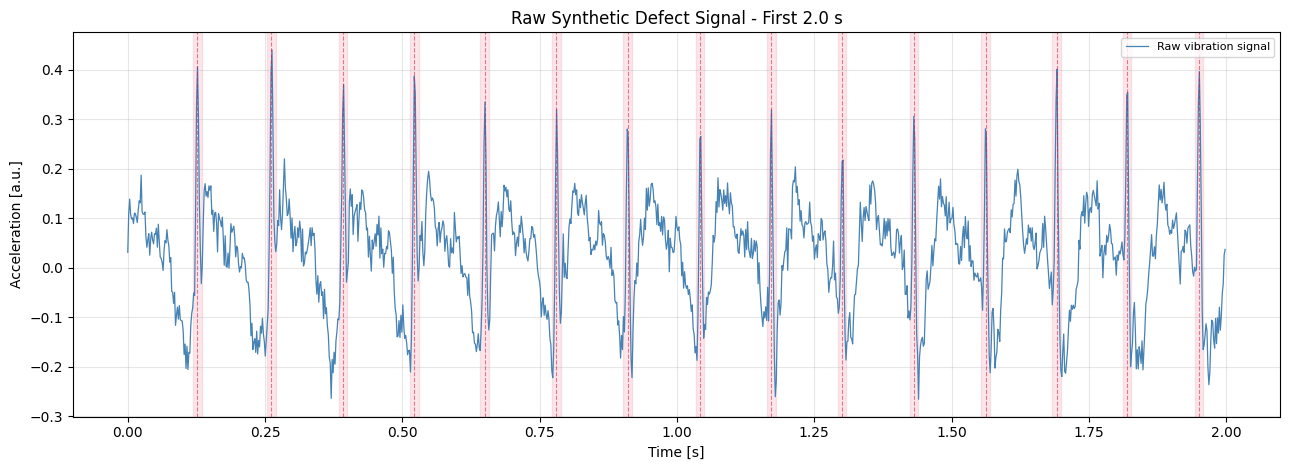

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

FS_HZ = 575
DURATION_SECONDS = 60
FOCUS_WINDOW_SECONDS = 2.0
EVENT_MARKER_HALF_WIDTH_S = 0.008

project_root = Path.cwd().resolve().parent
signal_path = project_root / "data" / "synthetic_defect_signal.npy"
event_path = project_root / "data" / "synthetic_defect_signal_event_times.npy"

x_full = np.load(signal_path).astype(np.float64)
event_times = np.load(event_path).astype(np.float64) if event_path.exists() else np.array([], dtype=np.float64)

assert x_full.ndim == 1, "Expected a 1D synthetic signal."
assert x_full.size == FS_HZ * DURATION_SECONDS, "Unexpected signal length for 60 s at 575 Hz."

focus_samples = max(1, int(FS_HZ * FOCUS_WINDOW_SECONDS))
x_focus = x_full[:focus_samples].copy()
time_s = np.arange(x_focus.size) / FS_HZ
event_times_focus = event_times[(event_times >= 0.0) & (event_times < FOCUS_WINDOW_SECONDS)]

print(f"Signal path: {signal_path}")
print(f"Full signal shape: {x_full.shape}, dtype: {x_full.dtype}")
print(f"Focus signal shape ({FOCUS_WINDOW_SECONDS:.1f} s): {x_focus.shape}")
print(f"Loaded event timestamps: {event_times.size}")
print(f"Event timestamps in first {FOCUS_WINDOW_SECONDS:.1f} s: {event_times_focus.size}")
print(
    f"Focus signal stats: mean={x_focus.mean():.6f}, std={x_focus.std():.6f}, "
    f"min={x_focus.min():.6f}, max={x_focus.max():.6f}"
)

fig, ax = plt.subplots(1, 1, figsize=(13, 4.8))
ax.plot(time_s, x_focus, linewidth=0.9, color="steelblue", label="Raw vibration signal")

for t_evt in event_times_focus:
    ax.axvspan(
        max(0.0, t_evt - EVENT_MARKER_HALF_WIDTH_S),
        min(FOCUS_WINDOW_SECONDS, t_evt + EVENT_MARKER_HALF_WIDTH_S),
        color="crimson",
        alpha=0.10,
    )
    ax.axvline(t_evt, color="crimson", linestyle="--", linewidth=0.8, alpha=0.55)

ax.set_title(f"Raw Synthetic Defect Signal - First {FOCUS_WINDOW_SECONDS:.1f} s")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Acceleration [a.u.]")
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

**Observations**:
The plotted raw segment shows visible high-frequency background fluctuations that can mask fine diagnostic structure, together with recurring sharp defect-like impulse peaks. This confirms the practical need for convolution-based smoothing in the next steps while highlighting that peak amplitude and temporal sharpness must be preserved as much as possible during subsequent processing and deconvolution.

The data context and representative raw signal segment are now established for the convolution and deconvolution workflow.

## Day 12 - Methodological Design

The methodological design below defines the theoretical assumptions, parameter mapping, baseline, and sweep logic used for reproducible implementation and evaluation.

### Theoretical Foundation and Method Choice

This investigation applies linear time-invariant filtering and inverse reconstruction to synthetic Swiss SBB bogie-vibration monitoring. Convolution with a normalized smoothing kernel is used to suppress high-frequency background noise, while Wiener deconvolution is used to recover sharp impact signatures attenuated by smoothing. The approach is valid when the smoothing kernel approximates the dominant blur process and noise remains moderate; if this model mismatch is large, deconvolution may amplify noise and create non-physical peaks.

### Parameter Definition and Mathematical Specification

The signal is sampled at fs=575 Hz and evaluated on a fixed 2.0 s window, so the analysis length is N=1150 samples. Smoothing is parameterized by kernel duration T_k in milliseconds, converted to samples by L_k=round(T_k*fs/1000), then forced to odd length for symmetric centering; tested values are 10 ms, 50 ms, and 180 ms. Deconvolution uses Wiener regularization lambda in the frequency domain with baseline lambda=0.01 and stress values lambda in {0.001, 0.1}. In this railway context, larger L_k increases noise suppression but broadens defect impulses, while larger lambda improves numerical stability at the cost of reduced peak restoration.

### Experimental Design for Next Days

The baseline configuration is defined as boxcar convolution with T_k=50 ms followed by Wiener deconvolution with lambda=0.01. The parameter sweep varies two factors: kernel duration T_k in {10, 50, 180} ms at fixed lambda=0.01, and regularization lambda in {0.001, 0.01, 0.1} at fixed T_k=50 ms. All metrics are computed on the same 2.0 s segment relative to the unfiltered raw reference and compared to the baseline configuration. It is theoretically expected that very short kernels under-suppress noise, very long kernels over-smooth defect peaks, and weak regularization in deconvolution increases instability through noise amplification.

### Methodological Limitations and Risk Factors

This approach assumes that smoothing blur can be approximated by a known stationary kernel and that event timing in the synthetic signal is representative for evaluation. The method is reliable when blur and noise characteristics are stable, but can become misleading when non-stationary disturbances or model mismatch dominate. In this use case, the main risk is deconvolution over-amplifying noise and producing visually sharp but diagnostically false peaks.

## Day 13 - Implementation

The implementation follows the Day 12 design with explicit baseline and parameter sweeps. The primary convolution is implemented manually in the spatial domain (zero-padding, sliding window, sum of products), while `np.convolve(..., mode="same")` is used only as a verification reference with a reported max-absolute difference per configuration.

Implementation summary table:
              config  kernel_ms  kernel_samples  reg_lambda  conv_verify_max_absdiff  rmse_conv  rmse_deconv  corr_deconv  peak_recovery_pct  snr_deconv_db  rmse_rel_change_pct_vs_baseline  peak_rel_change_pct_vs_baseline
    kernel10_lam0.01    10.0000               7      0.0100                   0.0000     0.0490       0.0243       0.9762            82.9515         3.9843                         -53.6006                          69.3042
   kernel50_lam0.001    50.0000              29      0.0010                   0.0000     0.0839       0.0458       0.9116            80.9699         3.1836                         -12.5387                          65.2598
baseline_k50_lam0.01    50.0000              29      0.0100                   0.0000     0.0839       0.0523       0.8841            48.9955        -0.0885                           0.0000                           0.0000
     kernel50_lam0.1    50.0000              29      0.1000                   0.00

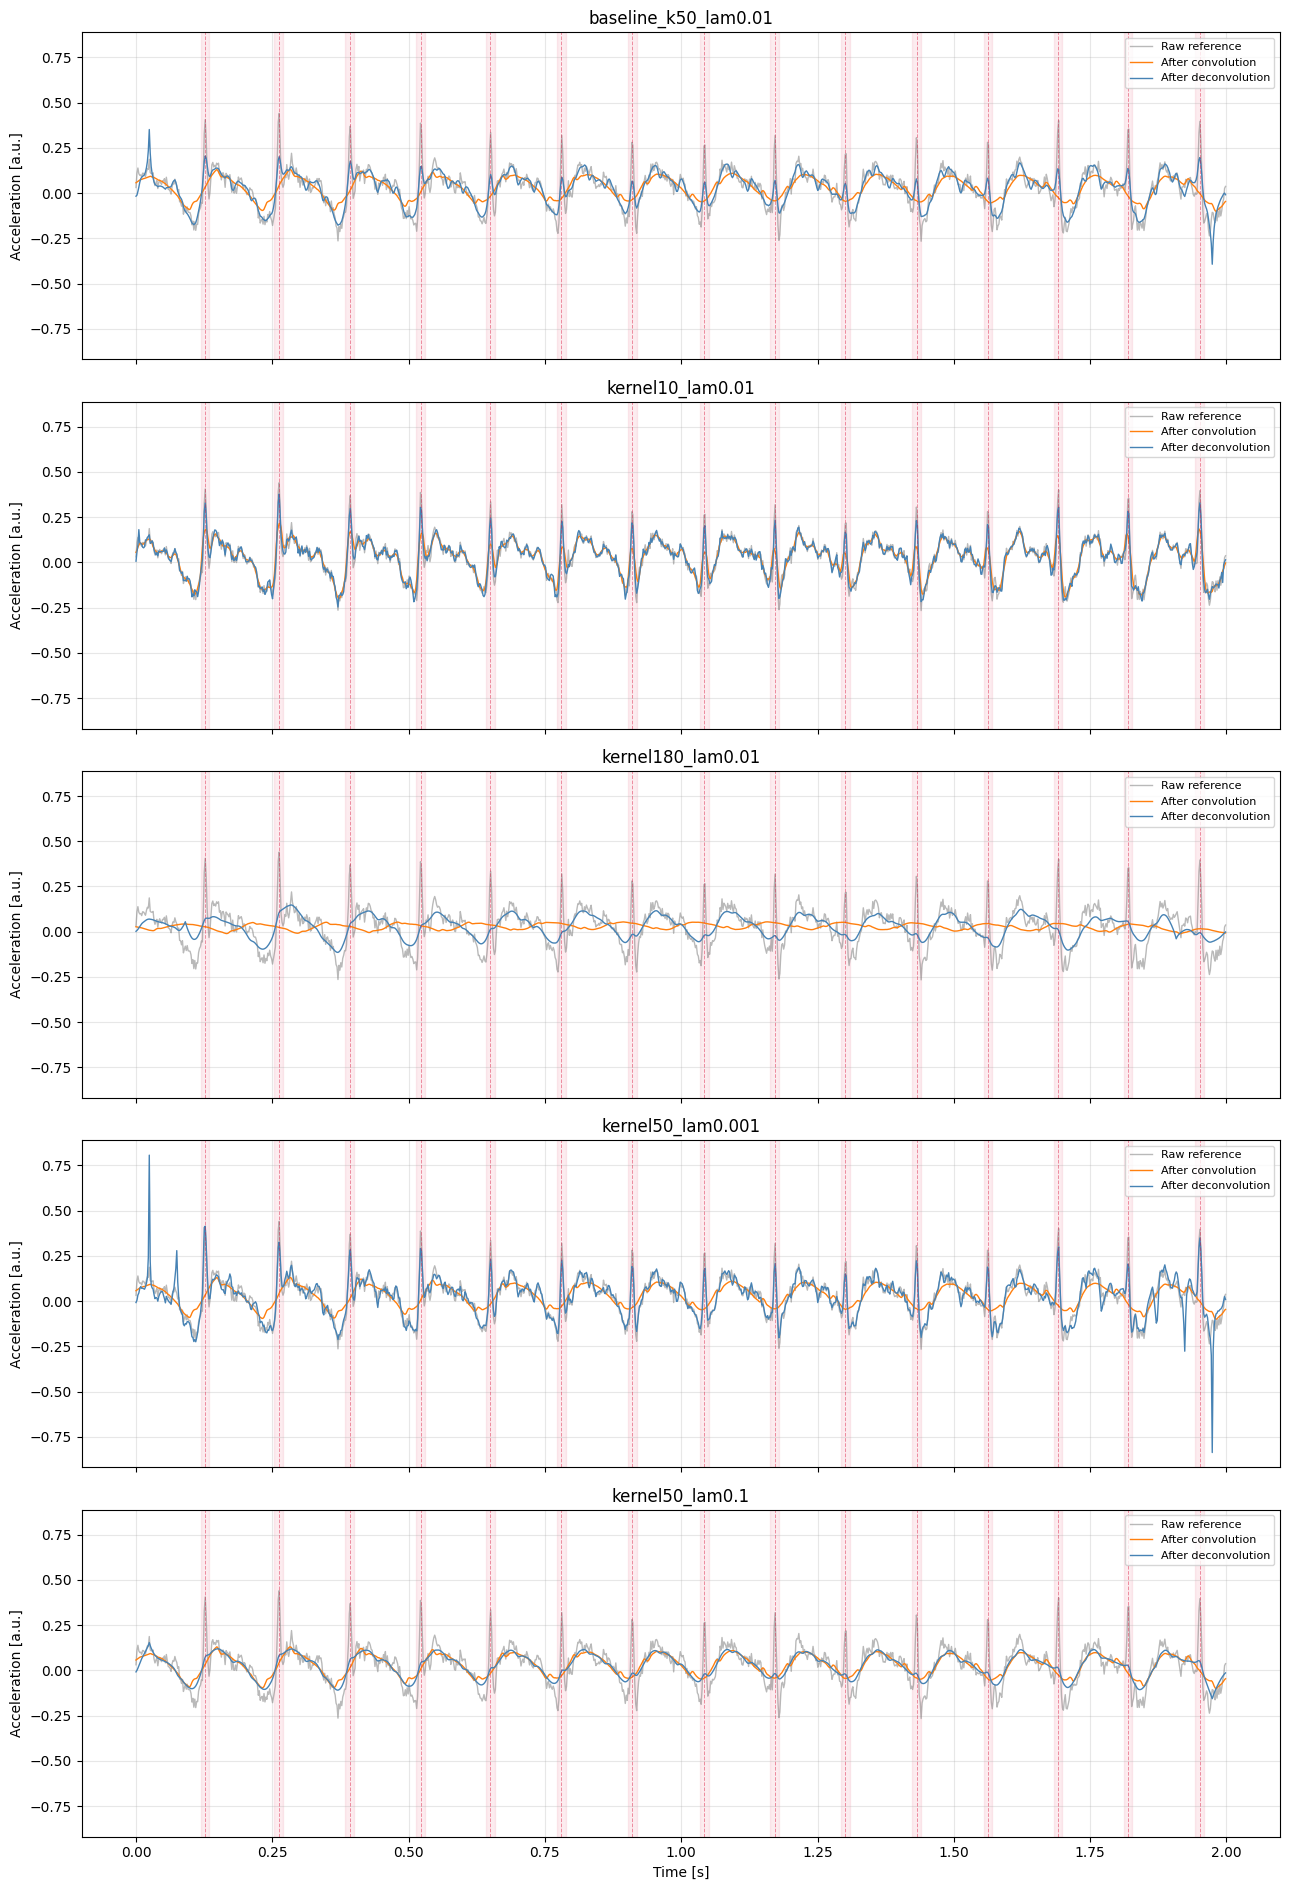

,config,kernel_ms,kernel_samples,reg_lambda,conv_verify_max_absdiff,rmse_conv,rmse_deconv,corr_deconv,peak_recovery_pct,snr_deconv_db,rmse_rel_change_pct_vs_baseline,peak_rel_change_pct_vs_baseline
1,kernel10_lam0.01,10.0,7,0.010,5.551115e-17,0.049027,0.024288,0.976196,82.951478,3.984341,-53.600645,69.304244
3,kernel50_lam0.001,50.0,29,0.001,5.551115e-17,0.083893,0.045782,0.911561,80.969877,3.183586,-12.538685,65.259790
0,baseline_k50_lam0.01,50.0,29,0.010,5.551115e-17,0.083893,0.052345,0.884062,48.995510,-0.088549,0.000000,0.000000
4,kernel50_lam0.1,50.0,29,0.100,5.551115e-17,0.083893,0.073037,0.772873,23.893988,-3.865482,39.529016,-51.232290
2,kernel180_lam0.01,180.0,105,0.010,3.469447e-17,0.117208,0.078727,0.725894,23.470793,-2.824731,50.398561,-52.096032


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def ms_to_odd_samples(duration_ms: float, fs_hz: int, minimum: int = 3) -> int:
    samples = max(minimum, int(round(duration_ms * fs_hz / 1000.0)))
    if samples % 2 == 0:
        samples += 1
    return samples


def make_boxcar_kernel(duration_ms: float, fs_hz: int) -> np.ndarray:
    length = ms_to_odd_samples(duration_ms, fs_hz)
    return np.ones(length, dtype=np.float64) / length


def manual_convolve_same(signal: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """Primary convolution implementation (manual, zero-padding, same length)."""
    n = signal.size
    k = kernel.size
    out = np.zeros(n, dtype=np.float64)
    center = k // 2

    for i in range(n):
        acc = 0.0
        for j in range(k):
            src_idx = i + j - center
            if 0 <= src_idx < n:
                acc += signal[src_idx] * kernel[j]
        out[i] = acc

    return out


def convolve_same_verified(signal: np.ndarray, kernel: np.ndarray) -> tuple[np.ndarray, float]:
    """Use manual convolution as primary output and np.convolve only for verification."""
    x_manual = manual_convolve_same(signal, kernel)
    x_lib = np.convolve(signal, kernel, mode="same")
    max_abs_diff = float(np.max(np.abs(x_manual - x_lib)))
    return x_manual, max_abs_diff


def wiener_deconvolution(observed: np.ndarray, kernel: np.ndarray, reg_lambda: float) -> np.ndarray:
    n = observed.size
    h = np.zeros(n, dtype=np.float64)
    h[: kernel.size] = kernel
    h = np.roll(h, -(kernel.size // 2))

    y_fft = np.fft.rfft(observed)
    h_fft = np.fft.rfft(h)
    deconv_fft = np.conj(h_fft) * y_fft / (np.abs(h_fft) ** 2 + reg_lambda)
    return np.fft.irfft(deconv_fft, n=n)


def build_event_mask(event_times_s: np.ndarray, signal_size: int, fs_hz: int, half_width_s: float) -> np.ndarray:
    mask = np.zeros(signal_size, dtype=bool)
    half_width = max(1, int(round(half_width_s * fs_hz)))
    for t_evt in event_times_s:
        center = int(round(t_evt * fs_hz))
        start = max(0, center - half_width)
        end = min(signal_size, center + half_width + 1)
        mask[start:end] = True
    return mask


def compute_event_peak_recovery_pct(reference: np.ndarray, candidate: np.ndarray, event_mask: np.ndarray) -> float:
    if not np.any(event_mask):
        return float("nan")
    ref_amp = float(np.mean(np.abs(reference[event_mask])))
    cand_amp = float(np.mean(np.abs(candidate[event_mask])))
    return cand_amp / (ref_amp + 1e-12) * 100.0


def compute_snr_db(signal: np.ndarray, event_mask: np.ndarray) -> float:
    if not np.any(event_mask):
        return float("nan")
    signal_rms = float(np.sqrt(np.mean(signal[event_mask] ** 2)))
    noise_region = ~event_mask
    noise_std = float(np.std(signal[noise_region])) if np.any(noise_region) else 1e-12
    return 20.0 * np.log10(signal_rms / (noise_std + 1e-12) + 1e-12)


def evaluate_configs(
    reference: np.ndarray,
    event_times_s: np.ndarray,
    fs_hz: int,
    half_width_s: float,
    configs: list[dict],
):
    records = []
    traces = {}
    event_mask = build_event_mask(event_times_s, reference.size, fs_hz, half_width_s)

    for cfg in configs:
        kernel = make_boxcar_kernel(cfg["kernel_ms"], fs_hz)
        x_conv, conv_verify_max_absdiff = convolve_same_verified(reference, kernel)
        x_deconv = wiener_deconvolution(x_conv, kernel, cfg["reg_lambda"])

        traces[cfg["config"]] = {
            "conv": x_conv,
            "deconv": x_deconv,
            "kernel": kernel,
        }

        records.append(
            {
                "config": cfg["config"],
                "kernel_ms": cfg["kernel_ms"],
                "kernel_samples": kernel.size,
                "reg_lambda": cfg["reg_lambda"],
                "conv_verify_max_absdiff": conv_verify_max_absdiff,
                "rmse_conv": float(np.sqrt(np.mean((reference - x_conv) ** 2))),
                "rmse_deconv": float(np.sqrt(np.mean((reference - x_deconv) ** 2))),
                "corr_deconv": float(np.corrcoef(reference, x_deconv)[0, 1]),
                "peak_recovery_pct": compute_event_peak_recovery_pct(reference, x_deconv, event_mask),
                "snr_deconv_db": compute_snr_db(x_deconv, event_mask),
            }
        )

    df = pd.DataFrame.from_records(records)
    baseline_mask = df["config"].str.contains("baseline")
    baseline_rmse = float(df.loc[baseline_mask, "rmse_deconv"].iloc[0])
    baseline_peak = float(df.loc[baseline_mask, "peak_recovery_pct"].iloc[0])
    df["rmse_rel_change_pct_vs_baseline"] = (df["rmse_deconv"] - baseline_rmse) / (baseline_rmse + 1e-12) * 100.0
    df["peak_rel_change_pct_vs_baseline"] = (df["peak_recovery_pct"] - baseline_peak) / (baseline_peak + 1e-12) * 100.0
    return df.sort_values(["kernel_ms", "reg_lambda"], ascending=[True, True]), traces


def plot_config_comparison(
    reference: np.ndarray,
    time_axis_s: np.ndarray,
    traces_map: dict,
    config_labels: list[str],
    event_times_s: np.ndarray,
    half_width_s: float,
    fs_hz: int,
) -> None:
    fig, axes = plt.subplots(len(config_labels), 1, figsize=(13, 3.8 * len(config_labels)), sharex=True, sharey=True)
    if len(config_labels) == 1:
        axes = [axes]

    for idx, cfg in enumerate(config_labels):
        ax = axes[idx]
        ax.plot(time_axis_s, reference, color="gray", linewidth=1.0, alpha=0.55, label="Raw reference")
        ax.plot(time_axis_s, traces_map[cfg]["conv"], color="tab:orange", linewidth=1.0, label="After convolution")
        ax.plot(time_axis_s, traces_map[cfg]["deconv"], color="steelblue", linewidth=1.0, label="After deconvolution")

        for t_evt in event_times_s:
            ax.axvspan(
                max(0.0, t_evt - half_width_s),
                min(time_axis_s[-1], t_evt + half_width_s),
                color="crimson",
                alpha=0.08,
            )
            ax.axvline(t_evt, color="crimson", linestyle="--", linewidth=0.7, alpha=0.45)

        ax.set_title(cfg)
        ax.set_ylabel("Acceleration [a.u.]")
        ax.grid(alpha=0.3)
        ax.legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("Time [s]")
    plt.tight_layout()
    plt.show()


EXPERIMENT_CONFIGS = [
    {"config": "baseline_k50_lam0.01", "kernel_ms": 50.0, "reg_lambda": 0.01},
    {"config": "kernel10_lam0.01", "kernel_ms": 10.0, "reg_lambda": 0.01},
    {"config": "kernel180_lam0.01", "kernel_ms": 180.0, "reg_lambda": 0.01},
    {"config": "kernel50_lam0.001", "kernel_ms": 50.0, "reg_lambda": 0.001},
    {"config": "kernel50_lam0.1", "kernel_ms": 50.0, "reg_lambda": 0.1},
]

results_df, traces = evaluate_configs(
    reference=x_focus,
    event_times_s=event_times_focus,
    fs_hz=FS_HZ,
    half_width_s=EVENT_MARKER_HALF_WIDTH_S,
    configs=EXPERIMENT_CONFIGS,
)

display_cols = [
    "config",
    "kernel_ms",
    "kernel_samples",
    "reg_lambda",
    "conv_verify_max_absdiff",
    "rmse_conv",
    "rmse_deconv",
    "corr_deconv",
    "peak_recovery_pct",
    "snr_deconv_db",
    "rmse_rel_change_pct_vs_baseline",
    "peak_rel_change_pct_vs_baseline",
]

print("Implementation summary table:")
print(results_df[display_cols].to_string(index=False, float_format="{:.4f}".format))

plot_config_comparison(
    reference=x_focus,
    time_axis_s=time_s,
    traces_map=traces,
    config_labels=["baseline_k50_lam0.01", "kernel10_lam0.01", "kernel180_lam0.01", "kernel50_lam0.001", "kernel50_lam0.1"],
    event_times_s=event_times_focus,
    half_width_s=EVENT_MARKER_HALF_WIDTH_S,
    fs_hz=FS_HZ,
)

results_df

## Day 14 - Evaluation

The predefined evaluation setup is applied consistently to all parameter configurations using the same 2.0 s signal segment, same event mask definition, and same baseline reference. All reported quantities are normalized or unit-labeled to keep results directly comparable across configurations.

### Evaluation Approach Definition

Three quantitative metrics are used consistently across all configurations: RMSE to the raw reference, Pearson correlation to the raw reference, and event-peak recovery ratio in percent at known defect timestamps. RMSE captures global reconstruction fidelity, correlation captures waveform-shape preservation, and peak recovery captures whether defect impulses remain diagnostically interpretable after convolution and deconvolution. This metric set is appropriate for the SBB context because maintenance relevance depends on both overall waveform consistency and local impulse visibility.

### Evaluation Comparison Execution

The influence of kernel duration and Wiener regularization is evaluated using the predefined metric set on the same fixed 2.0 s segment. Relative performance is computed against the baseline configuration T_k=50 ms and lambda=0.01 using percentage change in RMSE and peak recovery. Results are reported in structured tables and validated with comparative time-domain plots for baseline and stress configurations. No additional models or post-hoc parameter tuning are introduced during evaluation.

In [9]:
eval_cols = [
    "config",
    "kernel_ms",
    "reg_lambda",
    "rmse_deconv",
    "corr_deconv",
    "peak_recovery_pct",
    "snr_deconv_db",
    "rmse_rel_change_pct_vs_baseline",
    "peak_rel_change_pct_vs_baseline",
]

results_eval_df = results_df[eval_cols].copy().sort_values(["kernel_ms", "reg_lambda"])

print("Evaluation table (Convolution + Deconvolution):")
print(results_eval_df.to_string(index=False, float_format="{:.4f}".format))

best_rmse_idx = results_eval_df["rmse_deconv"].idxmin()
best_peak_idx = (results_eval_df["peak_recovery_pct"] - 100.0).abs().idxmin()

print()
print("Key checkpoints:")
print(f"Lowest RMSE deconv: {results_eval_df.loc[best_rmse_idx, 'config']}")
print(f"Closest peak recovery to 100%: {results_eval_df.loc[best_peak_idx, 'config']}")

results_eval_df

Evaluation table (Convolution + Deconvolution):
              config  kernel_ms  reg_lambda  rmse_deconv  corr_deconv  peak_recovery_pct  snr_deconv_db  rmse_rel_change_pct_vs_baseline  peak_rel_change_pct_vs_baseline
    kernel10_lam0.01    10.0000      0.0100       0.0243       0.9762            82.9515         3.9843                         -53.6006                          69.3042
   kernel50_lam0.001    50.0000      0.0010       0.0458       0.9116            80.9699         3.1836                         -12.5387                          65.2598
baseline_k50_lam0.01    50.0000      0.0100       0.0523       0.8841            48.9955        -0.0885                           0.0000                           0.0000
     kernel50_lam0.1    50.0000      0.1000       0.0730       0.7729            23.8940        -3.8655                          39.5290                         -51.2323
   kernel180_lam0.01   180.0000      0.0100       0.0787       0.7259            23.4708        -2.824

,config,kernel_ms,reg_lambda,rmse_deconv,corr_deconv,peak_recovery_pct,snr_deconv_db,rmse_rel_change_pct_vs_baseline,peak_rel_change_pct_vs_baseline
1,kernel10_lam0.01,10.0,0.010,0.024288,0.976196,82.951478,3.984341,-53.600645,69.304244
3,kernel50_lam0.001,50.0,0.001,0.045782,0.911561,80.969877,3.183586,-12.538685,65.259790
0,baseline_k50_lam0.01,50.0,0.010,0.052345,0.884062,48.995510,-0.088549,0.000000,0.000000
4,kernel50_lam0.1,50.0,0.100,0.073037,0.772873,23.893988,-3.865482,39.529016,-51.232290
2,kernel180_lam0.01,180.0,0.010,0.078727,0.725894,23.470793,-2.824731,50.398561,-52.096032


### Consolidated Evaluation Table (2.0 s window)

| Configuration | Kernel [ms] | Lambda [-] | RMSE after deconv [a.u.] | Correlation after deconv [-] | Peak recovery [%] | RMSE change vs baseline [%] |
|:--|--:|--:|--:|--:|--:|--:|
| baseline_k50_lam0.01 | 50 | 0.01 | 0.0523 | 0.8841 | 48.9955 | 0.0000 |
| kernel10_lam0.01 | 10 | 0.01 | 0.0243 | 0.9762 | 82.9515 | -53.6006 |
| kernel180_lam0.01 | 180 | 0.01 | 0.0787 | 0.7259 | 23.4708 | +50.3986 |
| kernel50_lam0.001 | 50 | 0.001 | 0.0458 | 0.9116 | 80.9699 | -12.5387 |
| kernel50_lam0.1 | 50 | 0.1 | 0.0730 | 0.7729 | 23.8940 | +39.5290 |

## Day 15 - Analysis and Communication

The following analysis is based strictly on the quantitative Day 14 outputs and focuses on practical implications for Swiss SBB predictive maintenance under the synthetic-signal setup.

### Observations

Across the tested configurations, RMSE after deconvolution ranges from 0.0243 (kernel10_lam0.01) to 0.0787 (kernel180_lam0.01), while the baseline is 0.0523. Correlation after deconvolution ranges from 0.7259 (kernel180_lam0.01) to 0.9762 (kernel10_lam0.01), with baseline at 0.8841. Peak recovery changes from 23.4708% (kernel180_lam0.01) and 23.8940% (kernel50_lam0.1) up to 82.9515% (kernel10_lam0.01), compared with 48.9955% in the baseline setup. The strongest quantitative improvement relative to baseline is obtained by kernel10_lam0.01 with RMSE reduction of 53.6006% and peak-recovery increase of 69.3042%.

### Interpretation

In this synthetic SBB monitoring scenario, short-kernel smoothing followed by moderate Wiener deconvolution preserves defect-impulse structure better than the baseline and long-kernel alternatives. The kernel10_lam0.01 result indicates that limiting blur before inversion is critical: less impulse broadening gives the deconvolution stage a better-conditioned recovery problem. Increasing regularization to lambda=0.1 suppresses instability but over-damps diagnostic peaks, while very long smoothing (180 ms) removes too much high-frequency defect detail to be recovered reliably. These trends imply that practical convolution/deconvolution design must prioritize impulse preservation first, then apply only the minimum smoothing needed for noise control.

### Discussion and Critical Reflection

For the defined use case, kernel10_lam0.01 performs best in this dataset because it combines low reconstruction error, high waveform correlation, and strong peak recovery, which aligns with the requirement to preserve early defect signatures for maintenance decisions. In contrast, kernel180_lam0.01 and kernel50_lam0.1 show reduced suitability due to strong attenuation of defect impulses and lower correlation to the reference signal. The achieved performance level is sufficient for controlled methodological benchmarking, but not yet sufficient to claim operational readiness for real SBB deployment. The current implementation assumes stationary blur and noise and uses a synthetic event structure with known timestamps; real measurements may violate these assumptions through non-stationary disturbances, variable speed, and sensor drift. To improve robustness, future work should validate parameter stability on measured multi-run SBB data and include false-positive/false-negative event detection metrics in addition to reconstruction metrics.

## Day 15

### Final Reflections on MC

Overall, the most successful aspect of MC1 was the consistent structure across sampling, correlation, and convolution tasks, particularly the use of fixed short analysis windows and baseline-relative comparisons for traceable decision-making. The convolution and deconvolution implementation worked well because the parameter sweep clearly exposed practical trade-offs between noise suppression and impulse preservation, leading to an evidence-based recommendation instead of a purely visual choice. If repeating this work, I would refine the deconvolution model with more realistic blur assumptions and add field-data validation to reduce the risk of synthetic-only bias. A key learning outcome was that mathematically valid inverse methods can still become diagnostically misleading when regularization or preprocessing is mismatched to the physical signal generation process.

### Revisions
- Replaced all template placeholders in Days 11-15 with project-specific text and executable analysis.
- Implemented convolution and Wiener deconvolution sweeps with explicit baseline and parameter stress tests.
- Added quantitative evaluation table and aligned Day 15 interpretation with measured results only.